### Distance Metrics & Effect of K in KNN

---

##### 1. Distance Metrics
Distance metrics measure how similar or different two data points are. They are important in algorithms like **K-Nearest Neighbors (KNN)**.

###### a) Euclidean Distance
- The “straight-line” distance between two points.  
- Formula (2D points):  
  \[
  d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}
  \]  
- Use when the scale of features is similar.  
- Example: Distance between (1,2) and (4,6) → \(\sqrt{(4-1)^2 + (6-2)^2} = 5\)

###### b) Manhattan Distance
- Also called **city-block distance** or **L1 norm**.  
- Measures distance along axes (like walking in a grid city).  
- Formula (2D points):  
  \[
  d = |x_2 - x_1| + |y_2 - y_1|
  \]  
- Example: Distance between (1,2) and (4,6) → \(|4-1| + |6-2| = 7\)  

**Key Difference:** Euclidean is straight line, Manhattan follows grid paths.  

---

##### 2. Effect of K Value on KNN Predictions
- **K** = Number of nearest neighbors considered to predict the class/value.  

**Impact:**  
1. **Small K (e.g., K=1)**  
   - Sensitive to noise → may overfit  
   - Predictions follow training points closely  

2. **Large K**  
   - Smoother predictions → less overfitting  
   - May underfit if too large → ignores local patterns  

**Rule of Thumb:**  
- Odd K for classification (avoid tie)  
- Choose K using **cross-validation** for best accuracy  

**Example:**  
- K=1 → prediction = class of the closest neighbor  
- K=5 → prediction = majority class among 5 nearest neighbors  


### Coding Tasks

### 1. Create a small 2-feature dataset manually (at least 8–10 records) with binary labels.

In [1]:
import csv
def load_numerical_dataset(filepath):
   X = []
   y = []
   with open(filepath, "r", newline="",encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                age = float(row["Age"])
                salary= float(row["EstimatedSalary"])
                purchased = int(row["Purchased"])
                X.append([age,salary])
                y.append(purchased)
            except:
                continue
        
        return X, y
X,y = load_numerical_dataset("Social_Network_Ads.csv")
# Lets print 10 values of both
print("2 features value",X[:10])
print("Labels",y[:10])
             
    

2 features value [[19.0, 19000.0], [35.0, 20000.0], [26.0, 43000.0], [27.0, 57000.0], [19.0, 76000.0], [27.0, 58000.0], [27.0, 84000.0], [32.0, 150000.0], [25.0, 33000.0], [35.0, 65000.0]]
Labels [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]


### 2. Write a function euclidean_distance(p1, p2) to compute distance between two points.

In [2]:
import math 

def euclidean_distance(p1,p2):
    return math.sqrt((p2[0]- p1[0])**2 + (p2[1] - p1[1])**2 )
# lets check for two datapoints 
p1 =[19.0, 19000.0]
p2= [35.0, 20000.0]

dis = euclidean_distance(p1,p2)
print("The Euclidean distance between two points is ",dis)

The Euclidean distance between two points is  1000.1279918090484


### 3. Modify the function to support N-dimensional vectors.

In [3]:
import math 

def euclidean_distance_nd(p1,p2):
    return sum((a-b)**2 for a,b in zip(p1,p2)) **0.5

# Test with 2D points 
p1 =[19.0, 19000.0]
p2= [35.0, 20000.0]
dis = euclidean_distance_nd(p1,p2)
print("The Euclidean distance between two points is ",dis)

# Test with 3D points
p3 = [19.0, 19000.0, 1.0]
p4 = [35.0, 20000.0, 3.0]

dis3d = euclidean_distance_nd(p3, p4)
print("Euclidean distance between 3D points is", dis3d)

The Euclidean distance between two points is  1000.1279918090484
Euclidean distance between 3D points is 1000.1299915510983


### 4. Write a function get_neighbors(X_train, x_test, k) that:
```
• calculates distances
• returns the k nearest neighbors

In [4]:
def get_neighbors(X_train, x_test, k):
    distances = []

    # 1. Calculate distance from x_test to every training point
    for i, x_train in enumerate(X_train):
        dist = euclidean_distance_nd(x_test, x_train)
        distances.append((i, dist))   # store index + distance

    # 2. Sort by distance
    distances.sort(key=lambda x: x[1])

    # 3. Take k nearest neighbors
    neighbors = distances[:k]

    return neighbors

x_test = [25.0, 20000.0]
k = 3
# lets take 10 datapoints for training
X_train = X[:10]
neighbors = get_neighbors(X_train, x_test, k)
print(neighbors)

[(1, 10.0), (0, 1000.0179998380029), (8, 13000.0)]


### 5. Write predict_knn(X_train, y_train, x_test, k) that predicts the most common label among neighbors.

In [5]:
def predict_knn(X_train, y_train, x_test, k):
    # 1. Get k nearest neighbors (index, distance)
    neighbors = get_neighbors(X_train, x_test, k)

    # 2. Collect labels of neighbors
    labels = []
    for idx, dist in neighbors:
        labels.append(y_train[idx])

    # 3. Majority voting
    prediction = max(set(labels), key=labels.count)

    return prediction

x_test = [25.0, 20000.0]
k = 3

X_train = X[:10]
y_train = y[:10]

pred = predict_knn(X_train, y_train, x_test, k)
print("Predicted label:", pred)

Predicted label: 0


### 6. Split your dataset into train and test manually (e.g., 70/30 split).

In [6]:
split_index = int(0.7 * len(X))
# 70% for training
X_train = X[:split_index]
y_train = y[:split_index]
#30% for testing
X_test = X[split_index:]
y_test = y[split_index:]



### 7. Write a loop to predict labels for every test sample.

In [7]:
# same code from 1 to 6 just imported for easy understanding

import csv
import math


# 1. Load dataset
def load_numerical_dataset(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                X.append([float(row["Age"]), float(row["EstimatedSalary"])])
                y.append(int(row["Purchased"]))
            except:
                continue
    return X, y

X, y = load_numerical_dataset("Social_Network_Ads.csv")

# 2. N-dimensional Euclidean distance
def euclidean_distance_nd(p1, p2):
    return sum((a - b) ** 2 for a, b in zip(p1, p2)) ** 0.5

# 3. Get k nearest neighbors
def get_neighbors(X_train, x_test, k):
    distances = []
    for i, x_train in enumerate(X_train):
        dist = euclidean_distance_nd(x_test, x_train)
        distances.append((i, dist))
    distances.sort(key=lambda x: x[1])
    return distances[:k]

# 4. Predict label for one point
def predict_knn(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    labels = [y_train[idx] for idx, _ in neighbors]
    prediction = max(set(labels), key=labels.count)
    return prediction

# 5. Train-test split (manual 70/30)
split_index = int(0.7 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_test = X[split_index:]
y_test = y[split_index:]


# 6. Predict all test points
k = 3
y_pred = []

for x in X_test:
    pred = predict_knn(X_train, y_train, x, k)
    y_pred.append(pred)

print("(Test,predicted)")
for yt,yp in zip(y_test,y_pred):
    print(yt, yp)

(Test,predicted)
1 1
0 0
1 0
1 0
0 1
1 1
0 0
1 1
0 0
1 0
1 1
1 0
1 0
0 0
0 0
0 0
1 0
1 0
0 0
1 1
1 0
1 0
1 1
1 0
0 0
0 0
0 1
1 0
1 1
0 0
0 0
1 1
0 0
1 1
0 0
1 0
1 1
0 0
1 0
0 0
1 1
1 0
0 0
1 0
1 1
0 0
0 0
0 0
1 0
1 1
0 0
1 1
0 0
0 0
1 0
0 0
1 1
0 0
0 0
1 1
1 1
0 0
0 0
1 0
1 1
0 0
1 0
1 1
0 0
0 0
1 0
0 0
1 1
0 0
1 1
1 0
1 0
0 0
1 0
0 0
1 1
1 0
1 0
0 0
1 1
1 1
1 0
1 1
0 0
1 1
1 0
1 0
0 0
1 1
0 0
1 0
0 0
0 0
1 0
1 0
0 0
1 0
1 1
1 1
1 0
1 0
1 0
0 0
1 0
1 0
1 0
1 0
1 0
1 0
0 0
1 0
1 0
1 0
0 0
1 0


### 8. Implement accuracy_score(y_true, y_pred) without using libraries.

In [8]:
def accuracy_score(y_true,y_pred):
    correct = 0 
    for actual, predicted in zip(y_true, y_pred):
        if actual == predicted:
            correct+=1

    accuracy  = (correct / len(y_pred)) * 100
    return accuracy
res = accuracy_score(y_test,y_pred)
print("The accuracy for this dataset is ",res)
        

The accuracy for this dataset is  60.83333333333333


### 9. Modify your code to support multi-class classification (at least 3 classes).

In [9]:
import math

# 1. Small 3-class dataset
XX = [
    [19, 20000],
    [22, 25000],
    [25, 30000],
    [28, 22000],
    [30, 35000],
    [21, 18000],
    [24, 27000],
    [26, 33000],
    [23, 20000],
    [29, 31000]
]

yy = [0, 1, 2, 1, 2, 0, 1, 2, 0, 2]

# 2. N-dimensional Euclidean distance
def euclidean_distance_nd(p1, p2):
    return sum((a - b) ** 2 for a, b in zip(p1, p2)) ** 0.5

# 3. Get k nearest neighbors
def get_neighbors(X_train, x_test, k):
    distances = []
    for i, x_train in enumerate(X_train):
        dist = euclidean_distance_nd(x_test, x_train)
        distances.append((i, dist))
    distances.sort(key=lambda x: x[1])
    return distances[:k]

# 4. Predict label for one point
def predict_knn(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    labels = [y_train[idx] for idx, _ in neighbors]
    prediction = max(set(labels), key=labels.count)
    return prediction

# 5. Train-test split (manual 70/30)
split_index = int(0.7 * len(XX))

X_train = XX[:split_index]
y_train = yy[:split_index]

X_test = XX[split_index:]
y_test = yy[split_index:]

# 6. Predict all test points
k = 3
y_pred = []

for xtest in X_test:
    pred = predict_knn(X_train, y_train, xtest, k)
    y_pred.append(pred)

print("(Test label, Predicted label)")
for yt, yp in zip(y_test, y_pred):
    print(yt, yp)

# 7. Accuracy calculation
def accuracy_score(y_true, y_pred):
    correct = sum(1 for a, p in zip(y_true, y_pred) if a == p)
    return correct / len(y_true) * 100

acc = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(acc))


(Test label, Predicted label)
2 2
0 0
2 2
Accuracy: 100.00%


### 10. Replace Euclidean distance with Manhattan distance and compare predictions.

In [10]:

import csv
import math


# 1. Load dataset
def load_numerical_dataset(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                X.append([float(row["Age"]), float(row["EstimatedSalary"])])
                y.append(int(row["Purchased"]))
            except:
                continue
    return X, y

X, y = load_numerical_dataset("Social_Network_Ads.csv")

# 2. N-dimensional manhattan distance
def manhattan_distance_nd(p1, p2):
    return sum(abs(a - b) for a, b in zip(p1, p2)) 

# 3. Get k nearest neighbors
def get_neighbors(X_train, x_test, k):
    distances = []
    for i, x_train in enumerate(X_train):
        dist = manhattan_distance_nd(x_test, x_train)
        distances.append((i, dist))
    distances.sort(key=lambda x: x[1])
    return distances[:k]

# 4. Predict label for one point
def predict_knn(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    labels = [y_train[idx] for idx, _ in neighbors]
    prediction = max(set(labels), key=labels.count)
    return prediction

# 5. Train-test split (manual 70/30)
split_index = int(0.7 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_test = X[split_index:]
y_test = y[split_index:]


def accuracy_score(y_true,y_pred):
    correct = 0 
    for actual, predicted in zip(y_true, y_pred):
        if actual == predicted:
            correct+=1

    accuracy  = (correct / len(y_pred)) * 100
    return accuracy

# 6. Predict all test points
k = 3
y_preds = []

for x in X_test:
    pred = predict_knn(X_train, y_train, x, k)
    y_preds.append(pred)

print("(Test,predicted)")
for yt,yp in zip(y_test,y_preds):
    print(yt, yp)
res = accuracy_score(y_test,y_preds)
print("The accuracy for this dataset is ",res)

(Test,predicted)
1 1
0 0
1 0
1 0
0 1
1 1
0 0
1 1
0 0
1 0
1 1
1 0
1 0
0 0
0 0
0 0
1 0
1 0
0 0
1 1
1 0
1 0
1 1
1 0
0 0
0 0
0 1
1 0
1 1
0 0
0 0
1 1
0 0
1 1
0 0
1 0
1 1
0 0
1 0
0 0
1 1
1 0
0 0
1 0
1 1
0 0
0 0
0 0
1 0
1 1
0 0
1 1
0 0
0 0
1 0
0 0
1 1
0 0
0 0
1 1
1 1
0 0
0 0
1 0
1 1
0 0
1 0
1 1
0 0
0 0
1 0
0 0
1 1
0 0
1 1
1 0
1 0
0 0
1 0
0 0
1 1
1 0
1 0
0 0
1 1
1 1
1 0
1 1
0 0
1 1
1 0
1 0
0 0
1 1
0 0
1 0
0 0
0 0
1 0
1 0
0 0
1 0
1 1
1 1
1 0
1 0
1 0
0 0
1 0
1 0
1 0
1 0
1 0
1 0
0 0
1 0
1 0
1 0
0 0
1 0
The accuracy for this dataset is  60.83333333333333


### 11. Add feature scaling (min-max normalization) and observe the effect on accuracy.

In [11]:
import csv
import math

# 1. Load dataset
def load_numerical_dataset(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                X.append([float(row["Age"]), float(row["EstimatedSalary"])])
                y.append(int(row["Purchased"]))
            except:
                continue
    return X, y

X, y = load_numerical_dataset("Social_Network_Ads.csv")

# 2. N-dimensional Euclidean distance
def euclidean_distance_nd(p1, p2):
    return sum((a - b) ** 2 for a, b in zip(p1, p2)) ** 0.5

# 3. Get k nearest neighbors
def get_neighbors(X_train, x_test, k):
    distances = []
    for i, x_train in enumerate(X_train):
        dist = euclidean_distance_nd(x_test, x_train)
        distances.append((i, dist))
    distances.sort(key=lambda x: x[1])
    return distances[:k]

# 4. Predict label for one point
def predict_knn(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    labels = [y_train[idx] for idx, _ in neighbors]
    prediction = max(set(labels), key=labels.count)
    return prediction

# 5. Train-test split (manual 70/30)
split_index = int(0.7 * len(X))
X_train = X[:split_index]
y_train = y[:split_index]
X_test = X[split_index:]
y_test = y[split_index:]

# 6. Min-Max Scaling
def min_max_scaling(X_train, X_test):
    X_train_scaled = []
    X_test_scaled = []

    features_train = list(zip(*X_train))
    min_vals = [min(f) for f in features_train]
    max_vals = [max(f) for f in features_train]

    # Scale training data
    for row in X_train:
        X_train_scaled.append([
            (val - min_vals[i]) / (max_vals[i] - min_vals[i])
            for i, val in enumerate(row)
        ])
    # Scale test data
    for row in X_test:
        X_test_scaled.append([
            (val - min_vals[i]) / (max_vals[i] - min_vals[i])
            for i, val in enumerate(row)
        ])
    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = min_max_scaling(X_train, X_test)

# 7. Accuracy function
def accuracy_score(y_true, y_pred):
    correct = sum(1 for a, p in zip(y_true, y_pred) if a == p)
    return correct / len(y_true) * 100

# 8. Predict all test points (scaled)
k = 3
y_pred_scaled = []

for xtest in X_test_scaled:
    pred = predict_knn(X_train_scaled, y_train, xtest, k)
    y_pred_scaled.append(pred)
print("Y_pred_scaled",y_pred_scaled[:5])
acc_scaled = accuracy_score(y_test, y_pred_scaled)
print("Accuracy with Min-Max Scaling for Eucledian: {:.2f}%".format(acc_scaled))


Y_pred_scaled [1, 0, 0, 1, 1]
Accuracy with Min-Max Scaling for Eucledian: 85.00%


In [12]:

import csv
import math


# 1. Load dataset
def load_numerical_dataset(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                X.append([float(row["Age"]), float(row["EstimatedSalary"])])
                y.append(int(row["Purchased"]))
            except:
                continue
    return X, y

X, y = load_numerical_dataset("Social_Network_Ads.csv")

# 2. N-dimensional manhattan distance
def manhattan_distance_nd(p1, p2):
    return sum(abs(a - b) for a, b in zip(p1, p2)) 

# 3. Get k nearest neighbors
def get_neighbors(X_train, x_test, k):
    distances = []
    for i, x_train in enumerate(X_train):
        dist = manhattan_distance_nd(x_test, x_train)
        distances.append((i, dist))
    distances.sort(key=lambda x: x[1])
    return distances[:k]

# 4. Predict label for one point
def predict_knn(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    labels = [y_train[idx] for idx, _ in neighbors]
    prediction = max(set(labels), key=labels.count)
    return prediction

# 5. Train-test split (manual 70/30)
split_index = int(0.7 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_test = X[split_index:]
y_test = y[split_index:]

def min_max_scaling(X_train, X_test):
    X_train_scaled = []
    X_test_scaled = []

    features_train = list(zip(*X_train))
    min_vals = [min(f) for f in features_train]
    max_vals = [max(f) for f in features_train]

    # Scale training data
    for row in X_train:
        X_train_scaled.append([
            (val - min_vals[i]) / (max_vals[i] - min_vals[i])
            for i, val in enumerate(row)
        ])
    # Scale test data
    for row in X_test:
        X_test_scaled.append([
            (val - min_vals[i]) / (max_vals[i] - min_vals[i])
            for i, val in enumerate(row)
        ])
    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = min_max_scaling(X_train, X_test)

# 7. Accuracy function
def accuracy_score(y_true, y_pred):
    correct = sum(1 for a, p in zip(y_true, y_pred) if a == p)
    return correct / len(y_true) * 100

# 8. Predict all test points (scaled)
k = 3
y_pred_scaled = []

for xtest in X_test_scaled:
    pred = predict_knn(X_train_scaled, y_train, xtest, k)
    y_pred_scaled.append(pred)
print("Y_pred_scaled",y_pred_scaled[:5])
acc_scaled = accuracy_score(y_test, y_pred_scaled)
print("Accuracy with Min-Max Scaling for Mahnattan: {:.2f}%".format(acc_scaled))



Y_pred_scaled [1, 0, 0, 1, 1]
Accuracy with Min-Max Scaling for Mahnattan: 84.17%


### 12. Write code to automatically choose the best K based on validation accuracy.

In [13]:
import csv
import math

# 1. Load dataset
def load_numerical_dataset(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                X.append([float(row["Age"]), float(row["EstimatedSalary"])])
                y.append(int(row["Purchased"]))
            except:
                continue
    return X, y

X, y = load_numerical_dataset("Social_Network_Ads.csv")

# 2. N-dimensional Euclidean distance
def euclidean_distance_nd(p1, p2):
    return sum((a - b) ** 2 for a, b in zip(p1, p2)) ** 0.5

# 3. KNN helper functions
def get_neighbors(X_train, x_test, k):
    distances = []
    for i, x_train in enumerate(X_train):
        dist = euclidean_distance_nd(x_test, x_train)
        distances.append((i, dist))
    distances.sort(key=lambda x: x[1])
    return distances[:k]

def predict_knn(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    labels = [y_train[idx] for idx, _ in neighbors]
    prediction = max(set(labels), key=labels.count)
    return prediction

def accuracy_score(y_true, y_pred):
    correct = sum(1 for a, p in zip(y_true, y_pred) if a == p)
    return correct / len(y_true) * 100

# 4. Train-test split (manual 70/30)
split_index = int(0.7 * len(X))
X_train_full = X[:split_index]
y_train_full = y[:split_index]
X_test = X[split_index:]
y_test = y[split_index:]

# 5. Further split train into train/validation (80/20)
split_val = int(0.8 * len(X_train_full))
X_train = X_train_full[:split_val]
y_train = y_train_full[:split_val]
X_val = X_train_full[split_val:]
y_val = y_train_full[split_val:]

# 6. Find best K
best_k = 1
best_acc = 0

for k in range(1, 11):  # Try K from 1 to 10
    y_val_pred = [predict_knn(X_train, y_train, x, k) for x in X_val]
    acc = accuracy_score(y_val, y_val_pred)
    print(f"K={k}, Validation Accuracy={acc:.2f}%")
    if acc > best_acc:
        best_acc = acc
        best_k = k

print(f"\nBest K based on validation accuracy: {best_k} (Accuracy={best_acc:.2f}%)")

# 7. Test with best K
y_test_pred = [predict_knn(X_train, y_train, x, best_k) for x in X_test]
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy with K={best_k}: {test_acc:.2f}%")


K=1, Validation Accuracy=73.21%
K=2, Validation Accuracy=66.07%
K=3, Validation Accuracy=76.79%
K=4, Validation Accuracy=75.00%
K=5, Validation Accuracy=75.00%
K=6, Validation Accuracy=73.21%
K=7, Validation Accuracy=75.00%
K=8, Validation Accuracy=71.43%
K=9, Validation Accuracy=75.00%
K=10, Validation Accuracy=71.43%

Best K based on validation accuracy: 3 (Accuracy=76.79%)
Test Accuracy with K=3: 57.50%


### 13. Add tie-breaking logic when two classes appear equally in neighbors.

In [33]:
import csv
import math

# 1. Load dataset
def load_numerical_dataset(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                X.append([float(row["Age"]), float(row["EstimatedSalary"])])
                y.append(int(row["Purchased"]))
            except:
                continue
    return X, y

X, y = load_numerical_dataset("Social_Network_Ads.csv")

# 2. N-dimensional Euclidean distance
def euclidean_distance_nd(p1, p2):
    return sum((a - b) ** 2 for a, b in zip(p1, p2)) ** 0.5

# 3. Get k nearest neighbors
def get_neighbors(X_train, x_test, k):
    distances = []
    for i, x_train in enumerate(X_train):
        dist = euclidean_distance_nd(x_test, x_train)
        distances.append((i, dist))
    distances.sort(key=lambda x: x[1])
    return distances[:k]

# 4. Predict label with tie-breaking
def predict_knn_tie(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    labels = [y_train[idx] for idx, _ in neighbors]

    # Count occurrences of each label
    label_count = {}
    for label in labels:
        label_count[label] = label_count.get(label, 0) + 1

    max_count = max(label_count.values())
    candidates = [label for label, count in label_count.items() if count == max_count]

    # If no tie, return directly
    if len(candidates) == 1:
        return candidates[0]

    # Tie-breaking: pick the label of the closest neighbor among tied classes
    for idx, _ in neighbors:
        if y_train[idx] in candidates:
            return y_train[idx]

# 5. Min-Max Scaling
def min_max_scaling(X_train, X_test):
    X_train_scaled = []
    X_test_scaled = []

    features_train = list(zip(*X_train))
    min_vals = [min(f) for f in features_train]
    max_vals = [max(f) for f in features_train]

    # Scale training data
    for row in X_train:
        X_train_scaled.append([
            (val - min_vals[i]) / (max_vals[i] - min_vals[i])
            for i, val in enumerate(row)
        ])
    # Scale test data
    for row in X_test:
        X_test_scaled.append([
            (val - min_vals[i]) / (max_vals[i] - min_vals[i])
            for i, val in enumerate(row)
        ])
    return X_train_scaled, X_test_scaled

# 6. Accuracy function
def accuracy_score(y_true, y_pred):
    correct = sum(1 for a, p in zip(y_true, y_pred) if a == p)
    return correct / len(y_true) * 100

# 7. Train-test split (70/30)
split_index = int(0.7 * len(X))
X_train = X[:split_index]
y_train = y[:split_index]
X_test = X[split_index:]
y_test = y[split_index:]

# Scale features
X_train_scaled, X_test_scaled = min_max_scaling(X_train, X_test)

# 8. Predict all test points with tie-breaking
k = 3
y_pred = []
for x in X_test_scaled:
    pred = predict_knn_tie(X_train_scaled, y_train, x, k)
    y_pred.append(pred)

# 9. Print results
# print("(Test, Predicted)")
# for yt, yp in zip(y_test, y_pred):
#     print(yt, yp)

acc = accuracy_score(y_test, y_pred)
print("Accuracy with Tie-Breaking: {:.2f}%".format(acc))


Accuracy with Tie-Breaking: 85.00%


### 14. Add distance-weighted voting (closer neighbors get more weight).

In [4]:
import csv
import math

# 1. Load dataset
def load_numerical_dataset(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                X.append([float(row["Age"]), float(row["EstimatedSalary"])])
                y.append(int(row["Purchased"]))
            except:
                continue
    return X, y

X, y = load_numerical_dataset("Social_Network_Ads.csv")

# 2. Euclidean distance (N-D)
def euclidean_distance_nd(p1, p2):
    return sum((a - b) ** 2 for a, b in zip(p1, p2)) ** 0.5

# 3. Get k nearest neighbors
def get_neighbors(X_train, x_test, k):
    distances = []
    for i, x_train in enumerate(X_train):
        dist = euclidean_distance_nd(x_test, x_train)
        distances.append((i, dist))
    distances.sort(key=lambda x: x[1])
    return distances[:k]

# 4. Distance-weighted KNN prediction
def predict_knn_weighted(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)

    label_weights = {}
    eps = 1e-6   # small value to avoid division by zero

    for idx, dist in neighbors:
        label = y_train[idx]
        weight = 1 / (dist + eps)

        if label not in label_weights:
            label_weights[label] = 0
        label_weights[label] += weight

    # pick label with highest total weight
    prediction = max(label_weights, key=label_weights.get)
    return prediction

# 5. Accuracy function
def accuracy_score(y_true, y_pred):
    correct = 0
    for a, p in zip(y_true, y_pred):
        if a == p:
            correct += 1
    return (correct / len(y_true)) * 100

# 6. Train-test split (70/30)
split_index = int(0.7 * len(X))
X_train = X[:split_index]
y_train = y[:split_index]
X_test = X[split_index:]
y_test = y[split_index:]

# 7. Predict test samples
k = 3
y_pred = []

for x in X_test:
    pred = predict_knn_weighted(X_train, y_train, x, k)
    y_pred.append(pred)

# 8. Results
# print("(Actual, Predicted)")
# for yt, yp in zip(y_test, y_pred):
#     print(yt, yp)

acc = accuracy_score(y_test, y_pred)
print("Accuracy (Distance-Weighted KNN):", acc)


Accuracy (Distance-Weighted KNN): 66.66666666666666


In [5]:
import csv
import math

# 1. Load dataset
def load_numerical_dataset(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                X.append([
                    float(row["Age"]),
                    float(row["EstimatedSalary"])
                ])
                y.append(int(row["Purchased"]))
            except:
                continue
    return X, y


X, y = load_numerical_dataset("Social_Network_Ads.csv")

# 2. Euclidean distance (N-dimensional)
def euclidean_distance_nd(p1, p2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p1, p2)))

# 3. Get k nearest neighbors
def get_neighbors(X_train, x_test, k):
    distances = []
    for i, x_train in enumerate(X_train):
        dist = euclidean_distance_nd(x_test, x_train)
        distances.append((i, dist))
    distances.sort(key=lambda x: x[1])
    return distances[:k]

# 4. Distance-weighted KNN prediction
def predict_knn_weighted(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)

    label_weights = {}
    eps = 1e-5  # avoids division by zero

    for idx, dist in neighbors:
        label = y_train[idx]
        weight = 1 / (dist + eps)

        label_weights[label] = label_weights.get(label, 0) + weight

    # class with highest total weight
    return max(label_weights, key=label_weights.get)

# 5. Min–Max Scaling
def min_max_scaling(X_train, X_test):
    X_train_scaled = []
    X_test_scaled = []

    features = list(zip(*X_train))
    min_vals = [min(f) for f in features]
    max_vals = [max(f) for f in features]

    for row in X_train:
        X_train_scaled.append([
            (row[i] - min_vals[i]) / (max_vals[i] - min_vals[i])
            for i in range(len(row))
        ])

    for row in X_test:
        X_test_scaled.append([
            (row[i] - min_vals[i]) / (max_vals[i] - min_vals[i])
            for i in range(len(row))
        ])

    return X_train_scaled, X_test_scaled

# 6. Accuracy function
def accuracy_score(y_true, y_pred):
    correct = sum(1 for a, p in zip(y_true, y_pred) if a == p)
    return (correct / len(y_true)) * 100

# 7. Train–test split (70 / 30)
split_index = int(0.7 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_test = X[split_index:]
y_test = y[split_index:]

# 8. Feature scaling (IMPORTANT)
X_train_scaled, X_test_scaled = min_max_scaling(X_train, X_test)

# 9. Prediction
k = 3
y_pred = []

for x in X_test_scaled:
    pred = predict_knn_weighted(X_train_scaled, y_train, x, k)
    y_pred.append(pred)

# 10. Result
acc = accuracy_score(y_test, y_pred)
print("Accuracy (Distance-Weighted KNN with Scaling): {:.2f}%".format(acc))


Accuracy (Distance-Weighted KNN with Scaling): 84.17%


### 15.Extend your implementation to work with higher-dimensional data (5+ features).

In [17]:
import math

# 1. 5-dimensional dataset
X = [
    [25, 30000, 2, 650, 5],
    [30, 40000, 5, 700, 6],
    [35, 50000, 7, 720, 4],
    [40, 60000, 10, 780, 3],
    [22, 28000, 1, 620, 6],
    [45, 65000, 12, 800, 2],
    [28, 35000, 3, 680, 5],
    [50, 70000, 15, 820, 1]
]

# Binary labels
y = [0, 0, 1, 1, 0, 1, 0, 1]

# 2. N-dimensional distance (already works!)
def euclidean_distance_nd(p1, p2):
    return sum((a - b) ** 2 for a, b in zip(p1, p2)) ** 0.5

# 3. Get neighbors
def get_neighbors(X_train, x_test, k):
    distances = []
    for i, x_train in enumerate(X_train):
        dist = euclidean_distance_nd(x_test, x_train)
        distances.append((i, dist))
    distances.sort(key=lambda x: x[1])
    return distances[:k]

# 4. Predict
def predict_knn(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    labels = [y_train[idx] for idx, _ in neighbors]
    return max(set(labels), key=labels.count)

# 5. Test prediction
x_test = [32, 42000, 6, 710, 5]  # 5 features
k = 3

pred = predict_knn(X, y, x_test, k)
print("Predicted label:", pred)


Predicted label: 0


### 16. Benchmark runtime when dataset grows from 50 → 500 → 5,000 samples and print the results.

In [18]:
import csv
import math
import time

# Load dataset
def load_numerical_dataset(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                X.append([float(row["Age"]), float(row["EstimatedSalary"])])
                y.append(int(row["Purchased"]))
            except:
                continue
    return X, y

X, y = load_numerical_dataset("Social_Network_Ads.csv")

# Euclidean distance
def euclidean_distance_nd(p1, p2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p1, p2)))

# Get k nearest neighbors
def get_neighbors(X_train, x_test, k):
    distances = [(i, euclidean_distance_nd(x_test, x_train)) for i, x_train in enumerate(X_train)]
    distances.sort(key=lambda x: x[1])
    return distances[:k]

# Distance-weighted KNN prediction
def predict_knn_weighted(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    eps = 1e-5
    label_weights = {}
    for idx, dist in neighbors:
        label = y_train[idx]
        weight = 1 / (dist + eps)
        label_weights[label] = label_weights.get(label, 0) + weight
    return max(label_weights, key=label_weights.get)

# Min–Max scaling
def min_max_scaling(X_train, X_test):
    X_train_scaled, X_test_scaled = [], []
    features = list(zip(*X_train))
    min_vals = [min(f) for f in features]
    max_vals = [max(f) for f in features]

    for row in X_train:
        X_train_scaled.append([(row[i] - min_vals[i]) / (max_vals[i] - min_vals[i]) for i in range(len(row))])
    for row in X_test:
        X_test_scaled.append([(row[i] - min_vals[i]) / (max_vals[i] - min_vals[i]) for i in range(len(row))])

    return X_train_scaled, X_test_scaled

# Benchmark KNN runtime
def benchmark_knn(train_size, k=3):
    # Take training subset
    X_train = X[:train_size]
    y_train = y[:train_size]
    
    # Use next 50 samples as test data
    test_end = min(train_size + 50, len(X))
    X_test = X[train_size:test_end]
    y_test = y[train_size:test_end]
    
    # Scale features
    X_train_scaled, X_test_scaled = min_max_scaling(X_train, X_test)
    
    # Measure runtime
    start = time.perf_counter()
    for x in X_test_scaled:
        predict_knn_weighted(X_train_scaled, y_train, x, k)
    end = time.perf_counter()
    
    return end - start

# Run benchmark for different training sizes
sizes = [100, 200, 300]    # my dataset has not  5000 data's so it give 0.0 s so checking for 100,200,300 for understanding
print("KNN Runtime Benchmark (Distance-Weighted)")
for size in sizes:
    runtime = benchmark_knn(size)
    print(f"Training samples: {size:<5} | Time: {runtime:.4f} seconds")


KNN Runtime Benchmark (Distance-Weighted)
Training samples: 100   | Time: 0.0234 seconds
Training samples: 200   | Time: 0.0505 seconds
Training samples: 300   | Time: 0.0804 seconds


In [ ]:
import csv
import math
def load_numerical_dataset(filepath):
    X,y = [],[]
    with open(filepath, "r", newline="", encoding = "utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                X.append([float(row["Age"]), float(row["EstimatedSalary"])])
                y.append(int(row["Purchased"]))
            except:
                continue
        return X, y

X,y = load_numerical_dataset("Social_Network_Ads.csv")

def euclidean_distance_nd(p1,p2):
    return math.sqrt(sum((a-b)**2 for a,b in zip(p1,p2)))

def get_neighbors(X_train,x_test,k):
    distances = []
    for i , x_train in enumerate(X_train):
        dist = euclidean_distance_nd(x_train,x_test)
        distances.append((i,dist))
    distances.sort(key= lambda x : x[1])
    neighbors = distances[:k]
    return neighbors

def predict_knn_tie(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    label_weight ={}
    eps = 1e-5
    for idx, dist in neighbors:
        label = y_train[idx]
        weight = 1/ (dist+eps)

        if label not in  label_weight:
            label_weight[label] = 0
        label_weight[label] += weight

    predictions = max(label_weight, key = label_weight.get)
    return predictions
        
def min_max_scaling(X_train,X_test):
    X_train_scaled =[]
    X_test_scaled = []
    features_train = list(zip(*X_train))
    min_vals = [min(f) for f in features_train]
    max_vals = [max(f) for f in features_train]

    for row in X_train:
        X_train_scaled.append([(val-min_vals[i]) / (max_vals[i] - min_vals[i]) for i,val in enumerate(row)])

    for row in X_test:
        X_test_scaled.append([(val-min_vals[i]) / (max_vals[i] - min_vals[i]) for i,val in enumerate(row)])

    return X_train_scaled, X_test_scaled

# 6. Accuracy function
def accuracy_score(y_true, y_pred):
    correct = sum(1 for a, p in zip(y_true, y_pred) if a == p)
    return correct / len(y_true) * 100

#split data 
def benchmarkk(trainsize,k=3):
    X_train = X[:trainsize]
    y_train = y[:trainsize]
    
    
## clling mean max scaled
X_trained_scaled , X_test_scaled = min_max_scaling(X_train, X_test)

k = 3
y_pred = []
for x in X_test_scaled:
    yval = predict_knn_tie(X_trained_scaled, y_train,x,k)
    y_pred.append(yval)
print(y_pred)

acc= accuracy_score(y_test,y_pred)
print(acc)

### 17. Plot decision boundary for KNN (using 2D features only).

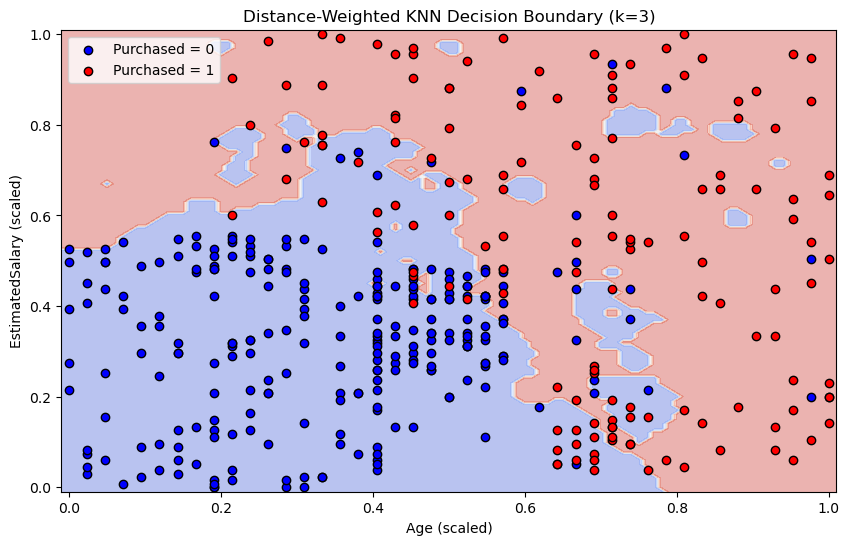

In [19]:
import csv
import math
import matplotlib.pyplot as plt

#  Load dataset 
def load_numerical_dataset(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                X.append([float(row["Age"]), float(row["EstimatedSalary"])])
                y.append(int(row["Purchased"]))
            except:
                continue
    return X, y

X, y = load_numerical_dataset("Social_Network_Ads.csv")

#  Euclidean distance 
def euclidean_distance_nd(p1, p2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p1, p2)))

#  Get neighbors 
def get_neighbors(X_train, x_test, k):
    distances = [(i, euclidean_distance_nd(x_test, x_train)) for i, x_train in enumerate(X_train)]
    distances.sort(key=lambda x: x[1])
    return distances[:k]

#  Distance-weighted KNN 
def predict_knn_weighted(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    eps = 1e-5
    label_weights = {}
    for idx, dist in neighbors:
        label = y_train[idx]
        weight = 1 / (dist + eps)
        label_weights[label] = label_weights.get(label, 0) + weight
    return max(label_weights, key=label_weights.get)

#  Min-Max scaling (pure Python) 
def min_max_scaling(X_train, X_test):
    features_train = list(zip(*X_train))
    min_vals = [min(f) for f in features_train]
    max_vals = [max(f) for f in features_train]

    X_train_scaled, X_test_scaled = [], []
    for row in X_train:
        X_train_scaled.append([(row[i]-min_vals[i])/(max_vals[i]-min_vals[i]) for i in range(len(row))])
    for row in X_test:
        X_test_scaled.append([(row[i]-min_vals[i])/(max_vals[i]-min_vals[i]) for i in range(len(row))])
    
    return X_train_scaled, X_test_scaled

#  Scale the dataset 
X_scaled, _ = min_max_scaling(X, X)  # scale full dataset

#  Create meshgrid (pure Python) 
h = 0.01
x_vals = [i * h for i in range(int(min([row[0] for row in X_scaled])*100)-1,
                               int(max([row[0] for row in X_scaled])*100)+2)]
y_vals = [i * h for i in range(int(min([row[1] for row in X_scaled])*100)-1,
                               int(max([row[1] for row in X_scaled])*100)+2)]

mesh_points = []
for xv in x_vals:
    for yv in y_vals:
        mesh_points.append([xv, yv])

#  Predict on meshgrid 
k = 3
Z = []
for point in mesh_points:
    Z.append(predict_knn_weighted(X_scaled, y, point, k))

# Convert Z to 2D list for contour plotting
Z_2d = []
for i in range(len(x_vals)):
    Z_2d.append(Z[i*len(y_vals):(i+1)*len(y_vals)])

# Plot decision boundary
plt.figure(figsize=(10,6))
plt.contourf(x_vals, y_vals, Z_2d, alpha=0.4, cmap=plt.cm.coolwarm)

# Plot original points with labels for legend
class0_X = [row[0] for i,row in enumerate(X_scaled) if y[i]==0]
class0_Y = [row[1] for i,row in enumerate(X_scaled) if y[i]==0]

class1_X = [row[0] for i,row in enumerate(X_scaled) if y[i]==1]
class1_Y = [row[1] for i,row in enumerate(X_scaled) if y[i]==1]

plt.scatter(class0_X, class0_Y, c='blue', label='Purchased = 0', edgecolor='k')
plt.scatter(class1_X, class1_Y, c='red', label='Purchased = 1', edgecolor='k')

plt.xlabel('Age (scaled)')
plt.ylabel('EstimatedSalary (scaled)')
plt.title(f'Distance-Weighted KNN Decision Boundary (k={k})')
plt.legend()
plt.show()


### 18. Compare test accuracy for K = 1, 3, 5, 7, 9.

In [20]:
import csv
import math

#  Load dataset 
def load_numerical_dataset(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                X.append([float(row["Age"]), float(row["EstimatedSalary"])])
                y.append(int(row["Purchased"]))
            except:
                continue
    return X, y

X, y = load_numerical_dataset("Social_Network_Ads.csv")

#  Euclidean distance 
def euclidean_distance_nd(p1, p2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p1, p2)))

#  Get neighbors 
def get_neighbors(X_train, x_test, k):
    distances = [(i, euclidean_distance_nd(x_test, x_train)) for i, x_train in enumerate(X_train)]
    distances.sort(key=lambda x: x[1])
    return distances[:k]

#  Distance-weighted KNN 
def predict_knn_weighted(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    eps = 1e-5
    label_weights = {}
    for idx, dist in neighbors:
        label = y_train[idx]
        weight = 1 / (dist + eps)
        label_weights[label] = label_weights.get(label, 0) + weight
    return max(label_weights, key=label_weights.get)

#  Min-Max scaling 
def min_max_scaling(X_train, X_test):
    features_train = list(zip(*X_train))
    min_vals = [min(f) for f in features_train]
    max_vals = [max(f) for f in features_train]

    X_train_scaled, X_test_scaled = [], []
    for row in X_train:
        X_train_scaled.append([(row[i]-min_vals[i])/(max_vals[i]-min_vals[i]) for i in range(len(row))])
    for row in X_test:
        X_test_scaled.append([(row[i]-min_vals[i])/(max_vals[i]-min_vals[i]) for i in range(len(row))])
    
    return X_train_scaled, X_test_scaled

#  Accuracy 
def accuracy_score(y_true, y_pred):
    correct = sum(1 for a, p in zip(y_true, y_pred) if a == p)
    return correct / len(y_true) * 100

#  Train-test split 
split_index = int(0.7 * len(X))
X_train = X[:split_index]
y_train = y[:split_index]
X_test = X[split_index:]
y_test = y[split_index:]

# Scale features
X_train_scaled, X_test_scaled = min_max_scaling(X_train, X_test)

# Compare accuracy for different k 
# k_values = [1, 3, 5, 7, 9]

# for k in k_values:
#     y_pred = [predict_knn_weighted(X_train_scaled, y_train, x, k) for x in X_test_scaled]
#     acc = accuracy_score(y_test, y_pred)
#     print(f"Accuracy for k={k}: {acc:.2f}%")

k_values = [1, 3, 5, 7, 9]

for k in k_values:
    y_pred = []  # reset for each k
    for x in X_test_scaled:
        y_pred.append(predict_knn_weighted(X_train_scaled, y_train, x, k))
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy for k={k}: {acc:.2f}%")


Accuracy for k=1: 77.50%
Accuracy for k=3: 84.17%
Accuracy for k=5: 85.83%
Accuracy for k=7: 85.00%
Accuracy for k=9: 85.00%


### 19. Add functionality to ignore missing values during distance calculation.

for these question if  i didn't allow dataset to have null , none values in the beigning as above we have done then there is no need of this below code 
the below code is just for understanding as we take null values here while loading dataset.

In [21]:
import csv
import math

#  Load dataset (allow None)  
def load_numerical_dataset_allow_missing(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                age = float(row["Age"]) if row["Age"] != "" else None
                salary = float(row["EstimatedSalary"]) if row["EstimatedSalary"] != "" else None
                purchased = int(row["Purchased"])  # assume label exists
                X.append([age, salary])
                y.append(purchased)
            except:
                continue
    return X, y

X, y = load_numerical_dataset_allow_missing("Social_Network_Ads.csv")

#  Min-Max scaling (ignore None) 
def min_max_scaling(X_train, X_test):
    # Compute min/max per feature ignoring None
    features_train = list(zip(*X_train))
    min_vals = [min([f for f in feat if f is not None]) for feat in features_train]
    max_vals = [max([f for f in feat if f is not None]) for feat in features_train]

    X_train_scaled, X_test_scaled = [], []
    for row in X_train:
        X_train_scaled.append([
            (row[i]-min_vals[i])/(max_vals[i]-min_vals[i]) if row[i] is not None else None
            for i in range(len(row))
        ])
    for row in X_test:
        X_test_scaled.append([
            (row[i]-min_vals[i])/(max_vals[i]-min_vals[i]) if row[i] is not None else None
            for i in range(len(row))
        ])
    return X_train_scaled, X_test_scaled

#  Euclidean distance (ignore None) 
def euclidean_distance_nd_ignore_missing(p1, p2):
    dist_sum = 0
    count = 0
    for a, b in zip(p1, p2):
        if a is not None and b is not None:
            dist_sum += (a - b)**2
            count += 1
    if count == 0:
        return float('inf')
    return math.sqrt(dist_sum)

#  Get neighbors 
def get_neighbors_ignore_missing(X_train, x_test, k):
    distances = [(i, euclidean_distance_nd_ignore_missing(x_test, x_train)) for i, x_train in enumerate(X_train)]
    distances.sort(key=lambda x: x[1])
    return distances[:k]

#  Distance-weighted KNN 
def predict_knn_weighted_ignore_missing(X_train, y_train, x_test, k):
    neighbors = get_neighbors_ignore_missing(X_train, x_test, k)
    eps = 1e-5
    label_weights = {}
    for idx, dist in neighbors:
        label = y_train[idx]
        weight = 1 / (dist + eps)
        label_weights[label] = label_weights.get(label, 0) + weight
    return max(label_weights, key=label_weights.get)

#  Accuracy 
def accuracy_score(y_true, y_pred):
    correct = sum(1 for a,p in zip(y_true, y_pred) if a==p)
    return correct / len(y_true) * 100

#  Train-test split 
split_index = int(0.7 * len(X))
X_train = X[:split_index]
y_train = y[:split_index]
X_test = X[split_index:]
y_test = y[split_index:]

# Scale features
X_train_scaled, X_test_scaled = min_max_scaling(X_train, X_test)

#  Predict 
k = 3
y_pred = [predict_knn_weighted_ignore_missing(X_train_scaled, y_train, x, k) for x in X_test_scaled]

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy with missing-value handling: {acc:.2f}%")


Accuracy with missing-value handling: 84.17%


### 20. Detect and remove duplicate rows before training.

In [22]:
import csv
import math

# ---------------- Load dataset ----------------
def load_numerical_dataset(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                X.append([float(row["Age"]), float(row["EstimatedSalary"])])
                y.append(int(row["Purchased"]))
            except:
                continue
    return X, y

# ---------------- Remove duplicate rows ----------------
def remove_duplicates(X, y):
    seen = set()
    X_new, y_new = [], []
    for features, label in zip(X, y):
        features_tuple = tuple(features)
        if features_tuple not in seen:
            seen.add(features_tuple)
            X_new.append(features)
            y_new.append(label)
    return X_new, y_new

# ---------------- Min-Max Scaling ----------------
def min_max_scaling(X_train, X_test):
    features_train = list(zip(*X_train))
    min_vals = [min(f) for f in features_train]
    max_vals = [max(f) for f in features_train]

    X_train_scaled, X_test_scaled = [], []
    for row in X_train:
        X_train_scaled.append([(row[i]-min_vals[i])/(max_vals[i]-min_vals[i]) for i in range(len(row))])
    for row in X_test:
        X_test_scaled.append([(row[i]-min_vals[i])/(max_vals[i]-min_vals[i]) for i in range(len(row))])
    return X_train_scaled, X_test_scaled

# ---------------- Euclidean distance ----------------
def euclidean_distance_nd(p1, p2):
    return math.sqrt(sum((a-b)**2 for a,b in zip(p1,p2)))

# ---------------- Get neighbors ----------------
def get_neighbors(X_train, x_test, k):
    distances = [(i, euclidean_distance_nd(x_test, x_train)) for i, x_train in enumerate(X_train)]
    distances.sort(key=lambda x: x[1])
    return distances[:k]

# ---------------- Distance-weighted KNN ----------------
def predict_knn_weighted(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    eps = 1e-5
    label_weights = {}
    for idx, dist in neighbors:
        label = y_train[idx]
        weight = 1 / (dist + eps)
        label_weights[label] = label_weights.get(label, 0) + weight
    return max(label_weights, key=label_weights.get)

# ---------------- Accuracy ----------------
def accuracy_score(y_true, y_pred):
    correct = sum(1 for a,p in zip(y_true, y_pred) if a==p)
    return correct / len(y_true) * 100

# ---------------- Main ----------------
# Load dataset
X, y = load_numerical_dataset("Social_Network_Ads.csv")

# Remove duplicate rows
X, y = remove_duplicates(X, y)
print(f"Dataset size after removing duplicates: {len(X)}")

# Train-test split (70/30)
split_index = int(0.7 * len(X))
X_train = X[:split_index]
y_train = y[:split_index]
X_test = X[split_index:]
y_test = y[split_index:]

# Scale features
X_train_scaled, X_test_scaled = min_max_scaling(X_train, X_test)

# Predict with distance-weighted KNN
k = 3
y_pred = [predict_knn_weighted(X_train_scaled, y_train, x, k) for x in X_test_scaled]

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy after removing duplicates: {acc:.2f}%")


Dataset size after removing duplicates: 365
Accuracy after removing duplicates: 81.82%


### 21. Implement cross-validation to evaluate performance.

In [23]:
import csv
import math

# ---------------- Load dataset ----------------
def load_numerical_dataset(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                X.append([float(row["Age"]), float(row["EstimatedSalary"])])
                y.append(int(row["Purchased"]))
            except:
                continue
    return X, y

# ---------------- Remove duplicate rows ----------------
def remove_duplicates(X, y):
    seen = set()
    X_new, y_new = [], []
    for features, label in zip(X, y):
        features_tuple = tuple(features)
        if features_tuple not in seen:
            seen.add(features_tuple)
            X_new.append(features)
            y_new.append(label)
    return X_new, y_new

# ---------------- Min-Max Scaling ----------------
def min_max_scaling(X_train, X_test):
    features_train = list(zip(*X_train))
    min_vals = [min(f) for f in features_train]
    max_vals = [max(f) for f in features_train]

    X_train_scaled, X_test_scaled = [], []
    for row in X_train:
        X_train_scaled.append([(row[i]-min_vals[i])/(max_vals[i]-min_vals[i]) for i in range(len(row))])
    for row in X_test:
        X_test_scaled.append([(row[i]-min_vals[i])/(max_vals[i]-min_vals[i]) for i in range(len(row))])
    return X_train_scaled, X_test_scaled

# ---------------- Euclidean distance ----------------
def euclidean_distance_nd(p1, p2):
    return math.sqrt(sum((a-b)**2 for a,b in zip(p1,p2)))

# ---------------- Get neighbors ----------------
def get_neighbors(X_train, x_test, k):
    distances = [(i, euclidean_distance_nd(x_test, x_train)) for i, x_train in enumerate(X_train)]
    distances.sort(key=lambda x: x[1])
    return distances[:k]

# ---------------- Distance-weighted KNN ----------------
def predict_knn_weighted(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    eps = 1e-5
    label_weights = {}
    for idx, dist in neighbors:
        label = y_train[idx]
        weight = 1 / (dist + eps)
        label_weights[label] = label_weights.get(label, 0) + weight
    return max(label_weights, key=label_weights.get)

# ---------------- Accuracy ----------------
def accuracy_score(y_true, y_pred):
    correct = sum(1 for a,p in zip(y_true, y_pred) if a==p)
    return correct / len(y_true) * 100

# ---------------- k-Fold Cross Validation ----------------
def cross_validation(X, y, k_neighbors=3, n_folds=5):
    fold_size = len(X) // n_folds
    accuracies = []

    for i in range(n_folds):
        start = i * fold_size
        end = start + fold_size
        X_test = X[start:end]
        y_test = y[start:end]
        X_train = X[:start] + X[end:]
        y_train = y[:start] + y[end:]

        # Scale features
        X_train_scaled, X_test_scaled = min_max_scaling(X_train, X_test)

        # Predict
        y_pred = [predict_knn_weighted(X_train_scaled, y_train, x, k_neighbors) for x in X_test_scaled]

        # Accuracy
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        print(f"Fold {i+1} Accuracy: {acc:.2f}%")

    avg_acc = sum(accuracies) / n_folds
    print(f"\nAverage Cross-Validation Accuracy: {avg_acc:.2f}%")
    return avg_acc

# ---------------- Main ----------------
X, y = load_numerical_dataset("Social_Network_Ads.csv")
X, y = remove_duplicates(X, y)
print(f"Dataset size after removing duplicates: {len(X)}")

# Run cross-validation
k_neighbors = 3
cross_validation(X, y, k_neighbors=k_neighbors, n_folds=5)


Dataset size after removing duplicates: 365
Fold 1 Accuracy: 94.52%
Fold 2 Accuracy: 93.15%
Fold 3 Accuracy: 83.56%
Fold 4 Accuracy: 83.56%
Fold 5 Accuracy: 80.82%

Average Cross-Validation Accuracy: 87.12%


87.12328767123287

### 22. Add a confusion matrix (manually coded, not using libraries).

In [24]:
import csv
import math

#  Load dataset 
def load_numerical_dataset(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                X.append([float(row["Age"]), float(row["EstimatedSalary"])])
                y.append(int(row["Purchased"]))
            except:
                continue
    return X, y

#  Remove duplicate rows 
def remove_duplicates(X, y):
    seen = set()
    X_new, y_new = [], []
    for features, label in zip(X, y):
        features_tuple = tuple(features)
        if features_tuple not in seen:
            seen.add(features_tuple)
            X_new.append(features)
            y_new.append(label)
    return X_new, y_new

#  Min-Max Scaling 
def min_max_scaling(X_train, X_test):
    features_train = list(zip(*X_train))
    min_vals = [min(f) for f in features_train]
    max_vals = [max(f) for f in features_train]

    X_train_scaled, X_test_scaled = [], []
    for row in X_train:
        X_train_scaled.append([(row[i]-min_vals[i])/(max_vals[i]-min_vals[i]) for i in range(len(row))])
    for row in X_test:
        X_test_scaled.append([(row[i]-min_vals[i])/(max_vals[i]-min_vals[i]) for i in range(len(row))])
    return X_train_scaled, X_test_scaled

#  Euclidean distance 
def euclidean_distance_nd(p1, p2):
    return math.sqrt(sum((a-b)**2 for a,b in zip(p1,p2)))

#  Get neighbors 
def get_neighbors(X_train, x_test, k):
    distances = [(i, euclidean_distance_nd(x_test, x_train)) for i, x_train in enumerate(X_train)]
    distances.sort(key=lambda x: x[1])
    return distances[:k]

#  Distance-weighted KNN 
def predict_knn_weighted(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    eps = 1e-5
    label_weights = {}
    for idx, dist in neighbors:
        label = y_train[idx]
        weight = 1 / (dist + eps)
        label_weights[label] = label_weights.get(label, 0) + weight
    return max(label_weights, key=label_weights.get)

#  Accuracy 
def accuracy_score(y_true, y_pred):
    correct = sum(1 for a,p in zip(y_true, y_pred) if a==p)
    return correct / len(y_true) * 100

#  Confusion matrix 
def confusion_matrix(y_true, y_pred):
    TP = TN = FP = FN = 0
    for actual, pred in zip(y_true, y_pred):
        if actual == 1 and pred == 1:
            TP += 1
        elif actual == 0 and pred == 0:
            TN += 1
        elif actual == 0 and pred == 1:
            FP += 1
        elif actual == 1 and pred == 0:
            FN += 1
    return [[TN, FP],
            [FN, TP]]

#  Main 
# Load and clean dataset
X, y = load_numerical_dataset("Social_Network_Ads.csv")
X, y = remove_duplicates(X, y)
print(f"Dataset size after removing duplicates: {len(X)}")

# Train-test split (70/30)
split_index = int(0.7 * len(X))
X_train = X[:split_index]
y_train = y[:split_index]
X_test = X[split_index:]
y_test = y[split_index:]

# Scale features
X_train_scaled, X_test_scaled = min_max_scaling(X_train, X_test)

# Predict using distance-weighted KNN
k = 3
y_pred = [predict_knn_weighted(X_train_scaled, y_train, x, k) for x in X_test_scaled]

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print("TN FP")
print("FN TP")
for row in cm:
    print(row)


Dataset size after removing duplicates: 365

Accuracy: 81.82%

Confusion Matrix:
TN FP
FN TP
[34, 2]
[18, 56]


### 23. Handle categorical features by encoding them.

In [25]:
import csv
import math

#  Load dataset 
def load_dataset(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                # Example: Gender is categorical (string), Age & Salary numeric
                X.append([row["Gender"], float(row["Age"]), float(row["EstimatedSalary"])])
                y.append(int(row["Purchased"]))
            except:
                continue
    return X, y

#  Encode categorical features 
def encode_categorical(X, categorical_indices):
    mappings = {}
    X_encoded = []

    for col_idx in categorical_indices:
        categories = list(set(row[col_idx] for row in X))
        mapping = {cat: i for i, cat in enumerate(categories)}
        mappings[col_idx] = mapping

    for row in X:
        new_row = row[:]
        for col_idx in categorical_indices:
            new_row[col_idx] = mappings[col_idx][row[col_idx]]
        X_encoded.append(new_row)

    return X_encoded, mappings

#  Remove duplicate rows 
def remove_duplicates(X, y):
    seen = set()
    X_new, y_new = [], []
    for features, label in zip(X, y):
        features_tuple = tuple(features)
        if features_tuple not in seen:
            seen.add(features_tuple)
            X_new.append(features)
            y_new.append(label)
    return X_new, y_new

#  Min-Max Scaling 
def min_max_scaling(X_train, X_test):
    features_train = list(zip(*X_train))
    min_vals = [min(f) for f in features_train]
    max_vals = [max(f) for f in features_train]

    X_train_scaled, X_test_scaled = [], []
    for row in X_train:
        X_train_scaled.append([(row[i]-min_vals[i])/(max_vals[i]-min_vals[i]) for i in range(len(row))])
    for row in X_test:
        X_test_scaled.append([(row[i]-min_vals[i])/(max_vals[i]-min_vals[i]) for i in range(len(row))])
    return X_train_scaled, X_test_scaled

#  Euclidean distance 
def euclidean_distance_nd(p1, p2):
    return math.sqrt(sum((a-b)**2 for a,b in zip(p1,p2)))

#  Get neighbors 
def get_neighbors(X_train, x_test, k):
    distances = [(i, euclidean_distance_nd(x_test, x_train)) for i, x_train in enumerate(X_train)]
    distances.sort(key=lambda x: x[1])
    return distances[:k]

#  Distance-weighted KNN 
def predict_knn_weighted(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    eps = 1e-5
    label_weights = {}
    for idx, dist in neighbors:
        label = y_train[idx]
        weight = 1 / (dist + eps)
        label_weights[label] = label_weights.get(label, 0) + weight
    return max(label_weights, key=label_weights.get)

#  Accuracy 
def accuracy_score(y_true, y_pred):
    correct = sum(1 for a,p in zip(y_true, y_pred) if a==p)
    return correct / len(y_true) * 100

#  Confusion matrix 
def confusion_matrix(y_true, y_pred):
    TP = TN = FP = FN = 0
    for actual, pred in zip(y_true, y_pred):
        if actual == 1 and pred == 1:
            TP += 1
        elif actual == 0 and pred == 0:
            TN += 1
        elif actual == 0 and pred == 1:
            FP += 1
        elif actual == 1 and pred == 0:
            FN += 1
    return [[TN, FP],
            [FN, TP]]

#  Main 
# Load dataset
X, y = load_dataset("Social_Network_Ads.csv")

# Encode categorical features (e.g., Gender column at index 0)
categorical_indices = [0]
X, mappings = encode_categorical(X, categorical_indices)
print("Categorical mappings:", mappings)

# Remove duplicates
X, y = remove_duplicates(X, y)
print(f"Dataset size after removing duplicates: {len(X)}")

# Train-test split (70/30)
split_index = int(0.7 * len(X))
X_train = X[:split_index]
y_train = y[:split_index]
X_test = X[split_index:]
y_test = y[split_index:]

# Scale features
X_train_scaled, X_test_scaled = min_max_scaling(X_train, X_test)

# Predict using distance-weighted KNN
k = 3
y_pred = [predict_knn_weighted(X_train_scaled, y_train, x, k) for x in X_test_scaled]

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.2f}%")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print("TN FP")
print("FN TP")
for row in cm:
    print(row)


Categorical mappings: {0: {'Female': 0, 'Male': 1}}
Dataset size after removing duplicates: 379

Accuracy: 71.05%

Confusion Matrix:
TN FP
FN TP
[34, 4]
[29, 47]


### 24. Compare your KNN results with a simple baseline (e.g., always predicting majority class).

In [26]:
import csv
import math

# ---------------- Load dataset ----------------
def load_dataset(filepath):
    X, y = [], []
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                # Example: Gender is categorical (string), Age & Salary numeric
                X.append([row["Gender"], float(row["Age"]), float(row["EstimatedSalary"])])
                y.append(int(row["Purchased"]))
            except:
                continue
    return X, y

# ---------------- Encode categorical features ----------------
def encode_categorical(X, categorical_indices):
    mappings = {}
    X_encoded = []

    for col_idx in categorical_indices:
        categories = list(set(row[col_idx] for row in X))
        mapping = {cat: i for i, cat in enumerate(categories)}
        mappings[col_idx] = mapping

    for row in X:
        new_row = row[:]
        for col_idx in categorical_indices:
            new_row[col_idx] = mappings[col_idx][row[col_idx]]
        X_encoded.append(new_row)

    return X_encoded, mappings

# ---------------- Remove duplicate rows ----------------
def remove_duplicates(X, y):
    seen = set()
    X_new, y_new = [], []
    for features, label in zip(X, y):
        features_tuple = tuple(features)
        if features_tuple not in seen:
            seen.add(features_tuple)
            X_new.append(features)
            y_new.append(label)
    return X_new, y_new

# ---------------- Min-Max Scaling ----------------
def min_max_scaling(X_train, X_test):
    features_train = list(zip(*X_train))
    min_vals = [min(f) for f in features_train]
    max_vals = [max(f) for f in features_train]

    X_train_scaled, X_test_scaled = [], []
    for row in X_train:
        X_train_scaled.append([(row[i]-min_vals[i])/(max_vals[i]-min_vals[i]) for i in range(len(row))])
    for row in X_test:
        X_test_scaled.append([(row[i]-min_vals[i])/(max_vals[i]-min_vals[i]) for i in range(len(row))])
    return X_train_scaled, X_test_scaled

# ---------------- Euclidean distance ----------------
def euclidean_distance_nd(p1, p2):
    return math.sqrt(sum((a-b)**2 for a,b in zip(p1,p2)))

# ---------------- Get neighbors ----------------
def get_neighbors(X_train, x_test, k):
    distances = [(i, euclidean_distance_nd(x_test, x_train)) for i, x_train in enumerate(X_train)]
    distances.sort(key=lambda x: x[1])
    return distances[:k]

# ---------------- Distance-weighted KNN ----------------
def predict_knn_weighted(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    eps = 1e-5
    label_weights = {}
    for idx, dist in neighbors:
        label = y_train[idx]
        weight = 1 / (dist + eps)
        label_weights[label] = label_weights.get(label, 0) + weight
    return max(label_weights, key=label_weights.get)

# ---------------- Accuracy ----------------
def accuracy_score(y_true, y_pred):
    correct = sum(1 for a,p in zip(y_true, y_pred) if a==p)
    return correct / len(y_true) * 100

# ---------------- Confusion matrix ----------------
def confusion_matrix(y_true, y_pred):
    TP = TN = FP = FN = 0
    for actual, pred in zip(y_true, y_pred):
        if actual == 1 and pred == 1:
            TP += 1
        elif actual == 0 and pred == 0:
            TN += 1
        elif actual == 0 and pred == 1:
            FP += 1
        elif actual == 1 and pred == 0:
            FN += 1
    return [[TN, FP],
            [FN, TP]]

# ---------------- Baseline Predictor ----------------
def baseline_majority(y_train, y_test):
    # Find majority class in training data
    majority_class = max(set(y_train), key=y_train.count)
    # Predict majority class for all test samples
    y_pred = [majority_class] * len(y_test)
    return y_pred

# ---------------- Main ----------------
# Load dataset
X, y = load_dataset("Social_Network_Ads.csv")

# Encode categorical features (e.g., Gender at index 0)
categorical_indices = [0]
X, mappings = encode_categorical(X, categorical_indices)

# Remove duplicates
X, y = remove_duplicates(X, y)
print(f"Dataset size after removing duplicates: {len(X)}")

# Train-test split (70/30)
split_index = int(0.7 * len(X))
X_train = X[:split_index]
y_train = y[:split_index]
X_test = X[split_index:]
y_test = y[split_index:]

# Scale features
X_train_scaled, X_test_scaled = min_max_scaling(X_train, X_test)

# --------- KNN Prediction ---------
k = 3
y_pred_knn = [predict_knn_weighted(X_train_scaled, y_train, x, k) for x in X_test_scaled]
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nKNN Accuracy: {acc_knn:.2f}%")

cm_knn = confusion_matrix(y_test, y_pred_knn)
print("\nKNN Confusion Matrix:")
print("TN FP")
print("FN TP")
for row in cm_knn:
    print(row)

# --------- Baseline Prediction ---------
y_pred_base = baseline_majority(y_train, y_test)
acc_base = accuracy_score(y_test, y_pred_base)
print(f"\nBaseline (Majority Class) Accuracy: {acc_base:.2f}%")

cm_base = confusion_matrix(y_test, y_pred_base)
print("\nBaseline Confusion Matrix:")
print("TN FP")
print("FN TP")
for row in cm_base:
    print(row)


Dataset size after removing duplicates: 379

KNN Accuracy: 71.05%

KNN Confusion Matrix:
TN FP
FN TP
[34, 4]
[29, 47]

Baseline (Majority Class) Accuracy: 33.33%

Baseline Confusion Matrix:
TN FP
FN TP
[38, 0]
[76, 0]


### 25. Save predictions to a CSV file and include predicted probability (from weighted votes).

In [27]:
import csv
import math

#  KNN Weighted Prediction (with probability) 
def predict_knn_weighted_with_prob(X_train, y_train, x_test, k):
    neighbors = get_neighbors(X_train, x_test, k)
    eps = 1e-5
    label_weights = {}
    
    for idx, dist in neighbors:
        label = y_train[idx]
        weight = 1 / (dist + eps)
        label_weights[label] = label_weights.get(label, 0) + weight
    
    total_weight = sum(label_weights.values())
    # Predicted label = one with max weight
    predicted_label = max(label_weights, key=label_weights.get)
    
    # Predicted probability = weight of predicted label / total weight
    predicted_prob = label_weights[predicted_label] / total_weight
    return predicted_label, predicted_prob

#  Save predictions to CSV 
def save_predictions_csv(filepath, X_test, y_pred_labels, y_pred_probs):
    header = ["Feature1", "Feature2", "Predicted_Label", "Predicted_Probability"]
    with open(filepath, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(header)
        for row, label, prob in zip(X_test, y_pred_labels, y_pred_probs):
            writer.writerow(row + [label, round(prob, 4)])

#  Main Example 
# Assuming X_train_scaled, y_train, X_test_scaled already prepared
k = 3
y_pred_labels = []
y_pred_probs = []

for x in X_test_scaled:
    label, prob = predict_knn_weighted_with_prob(X_train_scaled, y_train, x, k)
    y_pred_labels.append(label)
    y_pred_probs.append(prob)

# Save to CSV
save_predictions_csv("knn_predictions.csv", X_test_scaled, y_pred_labels, y_pred_probs)
print("Predictions saved to knn_predictions.csv")


Predictions saved to knn_predictions.csv
